In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

from IPython.display import display

In [2]:
os.chdir("/home/ganchao")

folderpath = Path("isilon/AllStaff/auditory/m96z")
# out_dir = Path("data/m96z_U331_phee_ant")
out_dir = Path("/home/ganchao/isilon/AllStaff/DCF/data/m96z_U331_phee_ant")
out_dir.mkdir(parents=True, exist_ok=True)

u_id = "U331"
target_call_type = "phee"
target_vocfile = "ant_m96z_S14_000001.txt"

mua_path = folderpath / f"m96z_{u_id}_playback_mua.mat"

In [3]:
def load_pbdata(path):
    mat = sio.loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False,
        simplify_cells=True,
    )
    return mat["pbdata"]

pbdata = load_pbdata(mua_path)
call_block = pbdata[target_call_type]

In [4]:
vocfiles = np.array(call_block["vocfiles"]).astype(str)
stim_idx = np.where(vocfiles == target_vocfile)[0][0]

sample_rate = float(pbdata["sample_rate"])
prestim = float(pbdata["prestim"])
poststim = float(pbdata["poststim"])
duration_ms = float(call_block["duration"][stim_idx])

print("u_id:", u_id)
print("stim_idx:", stim_idx)
print("vocfile:", target_vocfile)
print("sample_rate:", sample_rate)
print("prestim:", prestim)
print("poststim:", poststim)
print("duration_ms:", duration_ms)

u_id: U331
stim_idx: 0
vocfile: ant_m96z_S14_000001.txt
sample_rate: 1220.703125
prestim: 500.0
poststim: 500.0
duration_ms: 1806.0


In [5]:
channel_arrays = []

for ch_idx, ch_data in enumerate(call_block["mua"]):
    arr = np.asarray(ch_data[stim_idx], dtype=np.float32)

    if arr.ndim == 1:
        arr = arr[None, :]

    channel_arrays.append(arr)

n_trials = min(arr.shape[0] for arr in channel_arrays)
n_T = min(arr.shape[1] for arr in channel_arrays)
n_neuron = len(channel_arrays)

X = np.stack(
    [arr[:n_trials, :n_T] for arr in channel_arrays],
    axis=0,
)  # [n_neuron, n_trial, T]

X = np.transpose(X, (1, 2, 0))  # [n_trial, T, n_neuron]

time_ms = np.arange(n_T) / sample_rate * 1000.0 - prestim

print("X shape [n_trial, T, n_neuron]:", X.shape)

X shape [n_trial, T, n_neuron]: (5, 3426, 32)


In [6]:
trial_list = [X[i] for i in range(X.shape[0])]

print("n_trial:", len(trial_list))
print("one trial shape [T, n_neuron]:", trial_list[0].shape)

n_trial: 5
one trial shape [T, n_neuron]: (3426, 32)


In [7]:
head_df = pd.DataFrame(
    trial_list[0][:10, :8],
    columns=[f"ch_{i}" for i in range(8)]
)

head_df.insert(0, "time_ms", time_ms[:10])

display(head_df)

,time_ms,ch_0,ch_1,ch_2,ch_3,ch_4,ch_5,ch_6,ch_7
0,-500.0000,6.968359,0.0,13.198729,7.750826,8.053099,13.055327,7.629651,20.821207
1,-499.1808,32.068535,0.0,38.575981,31.318293,43.850998,35.408043,38.254604,63.829468
2,-498.3616,21.747196,0.0,26.196182,38.355526,45.551136,32.089748,43.040333,34.661694
3,-497.5424,22.972250,0.0,33.730747,41.378124,24.913445,41.547726,46.071857,35.854977
4,-496.7232,45.191154,0.0,40.704647,30.747543,32.514412,43.927917,51.118870,65.963982
5,-495.9040,29.889336,0.0,40.329811,26.058220,34.802322,28.239304,31.511768,81.310944
6,-495.0848,29.938139,0.0,29.185274,35.990456,38.343510,16.104921,39.883934,69.656189
7,-494.2656,48.467289,0.0,63.017422,38.675354,58.508583,40.927250,58.539639,55.144196
8,-493.4464,48.098698,0.0,79.366951,50.003178,46.272320,62.930798,48.992310,38.155262
9,-492.6272,39.477661,0.0,26.109180,44.323383,47.305489,29.342154,32.274849,27.847620


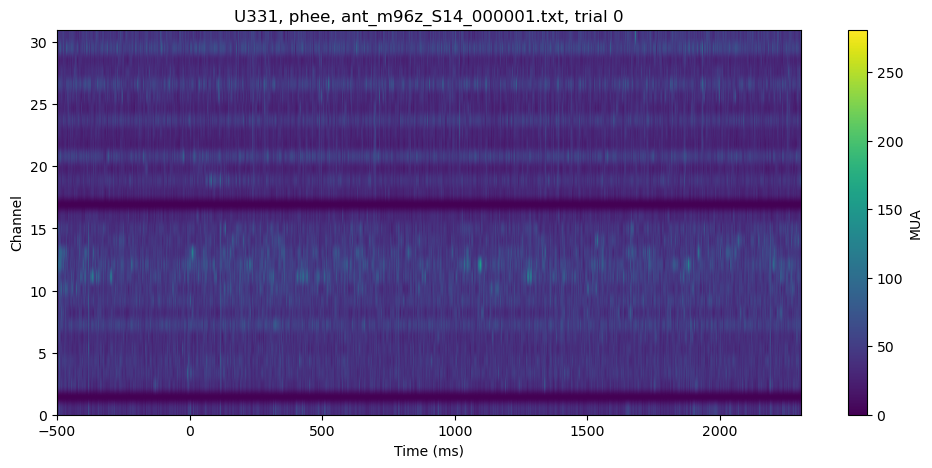

In [8]:
plt.figure(figsize=(12, 5))
plt.imshow(
    trial_list[0].T,
    aspect="auto",
    origin="lower",
    extent=[time_ms[0], time_ms[-1], 0, n_neuron - 1],
)
plt.xlabel("Time (ms)")
plt.ylabel("Channel")
plt.title(f"{u_id}, {target_call_type}, {target_vocfile}, trial 0")
plt.colorbar(label="MUA")
plt.show()

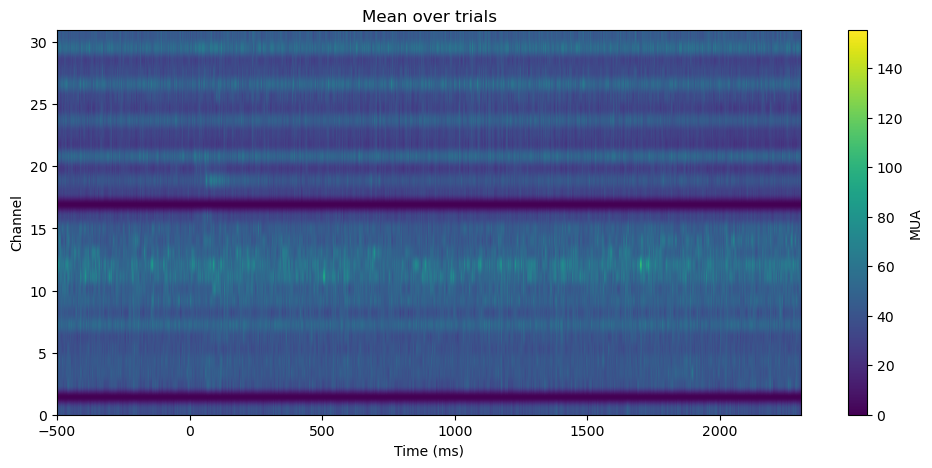

In [9]:
mean_trial = X.mean(axis=0)  # [T, n_neuron]

plt.figure(figsize=(12, 5))
plt.imshow(
    mean_trial.T,
    aspect="auto",
    origin="lower",
    extent=[time_ms[0], time_ms[-1], 0, n_neuron - 1],
)
plt.xlabel("Time (ms)")
plt.ylabel("Channel")
plt.title("Mean over trials")
plt.colorbar(label="MUA")
plt.show()

In [10]:
channel_mean = X.mean(axis=(0, 1), keepdims=True)
channel_std = X.std(axis=(0, 1), keepdims=True) + 1e-8

X_z = (X - channel_mean) / channel_std
trial_list_z = [X_z[i] for i in range(X_z.shape[0])]

print("X_z shape:", X_z.shape)
print("mean:", X_z.mean())
print("std:", X_z.std())

X_z shape: (5, 3426, 32)
mean: -2.1378339e-08
std: 0.9682459


In [11]:
np.savez(
    out_dir / "dataset_samples.npz",
    samples=X_z.astype(np.float32),
)

np.savez(
    out_dir / "dataset_samples_raw.npz",
    samples=X.astype(np.float32),
)

meta = {
    "u_id": u_id,
    "call_type": target_call_type,
    "vocfile": target_vocfile,
    "stim_idx": int(stim_idx),
    "sample_rate": sample_rate,
    "prestim": prestim,
    "poststim": poststim,
    "duration_ms": duration_ms,
    "shape": X.shape,
    "format": "[n_trial, T, n_neuron]",
    "channel_mean": channel_mean.squeeze().astype(np.float32),
    "channel_std": channel_std.squeeze().astype(np.float32),
    "time_ms": time_ms.astype(np.float32),
}

np.save(out_dir / "metadata.npy", meta, allow_pickle=True)

print("saved to:", out_dir)

saved to: /home/ganchao/isilon/AllStaff/DCF/data/m96z_U331_phee_ant
